# RFM CUSTOMER SEGMENTATION

Clean data loaded successfully for RFM analysis.

RFM CUSTOMER SEGMENTATION PROFILE TABLE
   Customer_Segment  Customer_Count  Avg_Recency_Days  Avg_Frequency_Orders  Total_Monetary_Pool  Avg_Monetary_Value  Churn_Count  Churn_Rate  Customer_Share_%  Monetary_Share_%
            At Risk            2050          8.133659              4.516585            402784.58          196.480283          234   11.414634         36.412078         40.368655
Potential Loyalists            1731          1.739457              1.209705            265825.30          153.567475          362   20.912767         30.746004         26.642057
    Loyal Customers            1485          2.430976              2.888215            264454.43          178.083791          312   21.010101         26.376554         26.504663
          Champions             162          1.691358              4.938272             36592.63          225.880432           20   12.345679          2.877442          3.667457
 Lost / Hibernating 

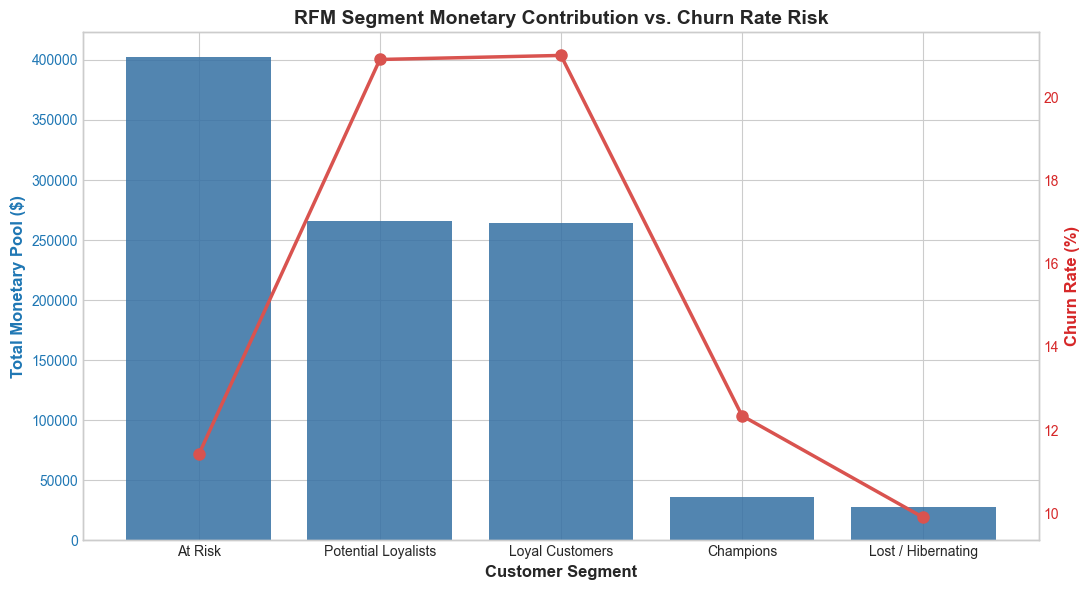

RFM customer segments saved to: C:\Users\AADHYA SHARMA\Downloads\customer-churn-revenue-intelligence\data\processed\rfm_customer_segments.csv


In [3]:
# Step 1: Setup & Project Paths
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = r"C:\Users\AADHYA SHARMA\Downloads\customer-churn-revenue-intelligence"
VISUALIZATIONS_DIR = os.path.join(BASE_DIR, "visualizations")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")

# Ensure folders exist
os.makedirs(VISUALIZATIONS_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')

# Load clean data
CLEAN_DATA_PATH = os.path.join(PROCESSED_DIR, "ecommerce_churn_clean.csv")
df = pd.read_csv(CLEAN_DATA_PATH)
print("Clean data loaded successfully for RFM analysis.")

# Step 2: RFM Metric Formulation
# Recency (R)   -> DaySinceLastOrder (Lower is better)
# Frequency (F) -> OrderCount (Higher is better)
# Monetary (M)  -> CashbackAmount (Higher is better)

rfm = df[['CustomerID', 'DaySinceLastOrder', 'OrderCount', 'CashbackAmount', 'Churn', 'Tenure']].copy()
rfm.rename(columns={
    'DaySinceLastOrder': 'Recency',
    'OrderCount': 'Frequency',
    'CashbackAmount': 'Monetary'
}, inplace=True)

# Step 3: Scoring Using Quantile Bins (1 to 5)
# Note: For Recency, lower days = higher quintile score (5)
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Combined RFM Score String & Numerical Composite
rfm['RFM_Combined'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Composite_Score'] = (rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']) / 3.0

# Step 4: Transparent Rule-Based Segmentation
def assign_rfm_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 3 and f < 3:
        return 'Potential Loyalists'
    elif r <= 2 and (f >= 3 or m >= 3):
        return 'At Risk'
    else:
        return 'Lost / Hibernating'

rfm['Customer_Segment'] = rfm.apply(assign_rfm_segment, axis=1)

# Step 5: Segment Performance & Churn Analysis
segment_profile = rfm.groupby('Customer_Segment').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency_Days=('Recency', 'mean'),
    Avg_Frequency_Orders=('Frequency', 'mean'),
    Total_Monetary_Pool=('Monetary', 'sum'),
    Avg_Monetary_Value=('Monetary', 'mean'),
    Churn_Count=('Churn', 'sum'),
    Churn_Rate=('Churn', lambda x: (x.mean() * 100))
).reset_index()

segment_profile['Customer_Share_%'] = (segment_profile['Customer_Count'] / len(rfm)) * 100
segment_profile['Monetary_Share_%'] = (segment_profile['Total_Monetary_Pool'] / rfm['Monetary'].sum()) * 100
segment_profile = segment_profile.sort_values(by='Total_Monetary_Pool', ascending=False)

print("\n" + "="*85)
print("RFM CUSTOMER SEGMENTATION PROFILE TABLE")
print("="*85)
print(segment_profile.to_string(index=False))

# Step 6: Visualization - RFM Segment Churn vs Monetary Contribution
fig, ax1 = plt.subplots(figsize=(11, 6))

color = 'tab:blue'
ax1.set_xlabel('Customer Segment', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Monetary Pool ($)', color=color, fontsize=12, fontweight='bold')
bars = ax1.bar(segment_profile['Customer_Segment'], segment_profile['Total_Monetary_Pool'], color='#3470a3', alpha=0.85)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Churn Rate (%)', color=color, fontsize=12, fontweight='bold')
lines = ax2.plot(segment_profile['Customer_Segment'], segment_profile['Churn_Rate'], color='#d9534f', marker='o', linewidth=2.5, markersize=8)
ax2.tick_params(axis='y', labelcolor=color)
ax2.grid(False)

plt.title('RFM Segment Monetary Contribution vs. Churn Rate Risk', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save figure using absolute path
fig_save_path = os.path.join(VISUALIZATIONS_DIR, "rfm_segment_treemap.png")
plt.savefig(fig_save_path, bbox_inches='tight')
print(f"Visualization saved to: {fig_save_path}")
plt.show()

# Step 7: Export Segmented File
rfm_save_path = os.path.join(PROCESSED_DIR, "rfm_customer_segments.csv")
rfm.to_csv(rfm_save_path, index=False)
print(f"RFM customer segments saved to: {rfm_save_path}")